# H0 vs OVR LR 오류 다양성 감사

새 blend나 제출을 만들지 않습니다. 최종 H0와 동일 structured+EB 입력의 OVR LR이 H0의 오답을 실질적으로 회복하는지만 확인합니다.

In [5]:
from pathlib import Path
import subprocess, sys, json
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

ROOT = Path('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton')
RUNNER = ROOT / 'experiments/gs/notebooks/exp_model_010/common/run_h0_ovr_diversity_audit.py'
RESULT = ROOT / 'experiments/gs/notebooks/exp_model_010/result'
RUN_ID = 'exp-h0-ovr-diversity-audit-01'
RUN_EXPERIMENT = True
assert RUNNER.exists()

In [6]:
subprocess.run([sys.executable, str(RUNNER), '--smoke'], check=True)

{"smoke": "ok", "test_read": false, "nan_as_mutation_count": 0, "ovr_n_jobs": 1}


CompletedProcess(args=['/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/.venv/bin/python', '/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/exp_model_010/common/run_h0_ovr_diversity_audit.py', '--smoke'], returncode=0)

In [7]:
if RUN_EXPERIMENT:
    process = subprocess.Popen([sys.executable, str(RUNNER), '--run-id', RUN_ID], stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
    tail = []
    for line in tqdm(process.stdout, desc='H0 / OVR diversity audit', unit='line'):
        print(line, end='')
        tail = (tail + [line])[-120:]
    if process.wait():
        raise RuntimeError('OVR diversity runner failed:\n' + ''.join(tail))
else:
    print('RUN_EXPERIMENT=False: 결과가 있다면 집계만 수행합니다.')

H0 / OVR diversity audit: 1line [00:04,  4.72s/line]

[OVR diversity] fold 1/5: H0 and same-input OVR


H0 / OVR diversity audit: 2line [04:59, 175.27s/line]

[OVR diversity] fold 2/5: H0 and same-input OVR


H0 / OVR diversity audit: 3line [10:25, 243.97s/line]

...

H0 / OVR diversity audit: 5line [21:16, 294.49s/line]

[OVR diversity] fold 5/5: H0 and same-input OVR


H0 / OVR diversity audit: 6line [26:16, 296.55s/line]

{"run_id": "exp-h0-ovr-diversity-audit-01", "h0_reference": 0.547915, "h0_reference_match": true, "h0_reference_delta": -3.387370274277046e-07, "test_read": false, "train_test_concat": false, "leakage_check": true, "nan_as_mutation_count": 0, "hard_prediction_disagreement_rate": 0.20754716981132076, "h0_wrong_ovr_recovered_count": 288, "h0_wrong_ovr_recovered_rate_of_all_rows": 0.04644412191582003, "h0_correct_ovr_broken_count": 355, "h0_correct_ovr_broken_rate_of_all_rows": 0.0572488308337365, "joint_wrong_count": 2447, "oracle_macro_f1_diagnostic_only": 0.587012249585215, "ovr_diversity_candidate": false}


H0 / OVR diversity audit: 6line [26:17, 262.91s/line]


In [8]:
summary = pd.read_csv(RESULT / f'{RUN_ID}_seed42_summary.csv')
folds = pd.read_csv(RESULT / f'{RUN_ID}_seed42_fold_metrics.csv')
classes = pd.read_csv(RESULT / f'{RUN_ID}_seed42_class_metrics.csv')
errors = pd.read_csv(RESULT / f'{RUN_ID}_seed42_error_overlap.csv')
audit = json.loads((RESULT / f'{RUN_ID}_seed42_diversity_audit.json').read_text())
assert summary.leakage_check.all() and summary.nan_as_mutation_count.eq(0).all()
display(summary)
display(folds.pivot(index='fold', columns='variant', values='macro_f1'))
display(pd.DataFrame([audit])[['hard_prediction_disagreement_rate', 'h0_wrong_ovr_recovered_count', 'h0_correct_ovr_broken_count', 'oracle_macro_f1_diagnostic_only', 'ovr_diversity_candidate']])

,variant,oof_macro_f1,oof_accuracy,feature_count,convergence_warning_count,leakage_check,nan_as_mutation_count,runtime_seconds,delta_vs_h0
0,H0_selective_EB,0.547915,0.558942,8219.2,0,True,0,1575.056580,0.000000
1,OVR_EB_LR,0.531134,0.548137,8219.2,0,True,0,1575.057287,-0.016781


variant,H0_selective_EB,OVR_EB_LR
fold,,
1,0.528516,0.509100
2,0.551891,0.545252
3,0.543449,0.506885
4,0.554759,0.553980
5,0.558499,0.538648


,hard_prediction_disagreement_rate,h0_wrong_ovr_recovered_count,h0_correct_ovr_broken_count,oracle_macro_f1_diagnostic_only,ovr_diversity_candidate
0,0.207547,288,355,0.587012,False


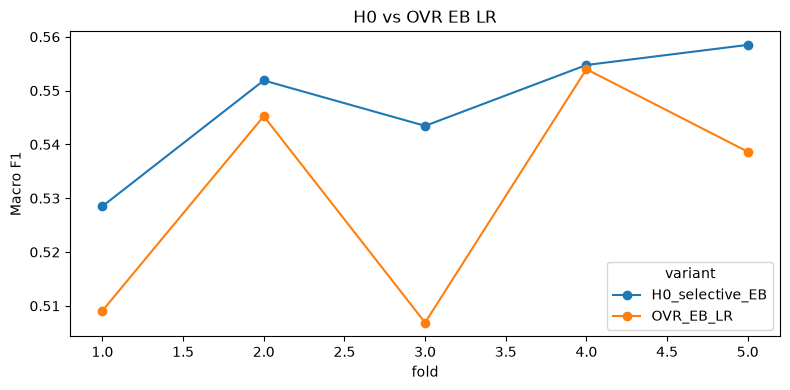

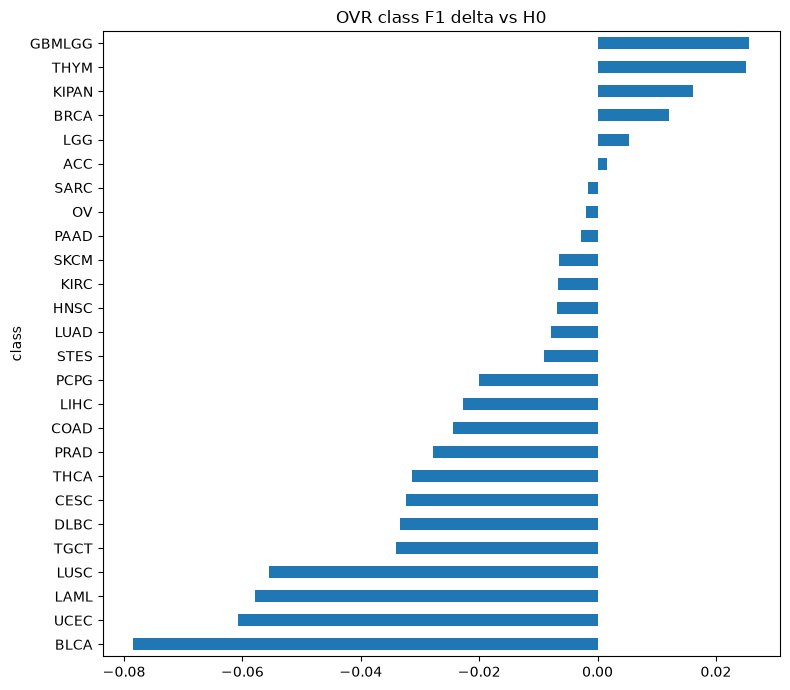

Recovered: 288 Broken: 355


In [9]:
folds.pivot(index='fold', columns='variant', values='macro_f1').plot(marker='o', figsize=(8,4), title='H0 vs OVR EB LR')
plt.ylabel('Macro F1'); plt.tight_layout(); plt.show()
classes.sort_values('f1_delta').set_index('class').f1_delta.plot.barh(figsize=(8,7), title='OVR class F1 delta vs H0')
plt.tight_layout(); plt.show()
print('Recovered:', int(errors.recovered_by_ovr.sum()), 'Broken:', int(errors.broken_by_ovr.sum()))